# EMCellFound KNN demo

In this demo, we employ the frozen EMCellFound model to classify eight organelles. A KNN classification head is appended after EMCellFound, with the EMCellFound backbone kept frozen.

Download the dataset

In [ ]:
import os
from huggingface_hub import snapshot_download
import pathlib
import sys
# Get the base directory of the project, which is the parent directory of the current working directory
BASE_DIR = pathlib.Path.cwd().resolve().parent
print(f"BASE_DIR: {BASE_DIR}")
# set the root directory of the project to the module search path
root = pathlib.Path(BASE_DIR)
# add the root directory to the module search path
sys.path.insert(0, str(root))


local_dir = (BASE_DIR / "demo" / "datasets_temp" / "EightOrganelleClassification")
snapshot_download(repo_id="Zeyu0102/EightOrganelleClassification", repo_type="dataset",
                  local_dir=local_dir,
                  local_dir_use_symlinks=False, 
                  resume_download=True)


import zipfile
# unzip the downloaded dataset
import os
zip_file = zipfile.ZipFile(os.path.join(local_dir, "OrganelleClassifyDataset.zip"), 'r')

dataset_dir = os.path.join(local_dir, "EightOrganelleClassification")
for file in zip_file.namelist():
   zip_file.extract(file, local_dir) 
zip_file.close()

print("OrganelleClassifyDataset downloaded and unzipped successfully.")

BASE_DIR: D:\napari_EMCF\EMCFsys\emcfsys


c:\Users\YZY\miniconda3\envs\EMCF_napari\Lib\site-packages\huggingface_hub\utils\_validators.py:189: UserWarning: The `resume_download` argument is deprecated and ignored in `snapshot_download`. Downloads always resume whenever possible.
  warnings.warn(
c:\Users\YZY\miniconda3\envs\EMCF_napari\Lib\site-packages\huggingface_hub\utils\_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `snapshot_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Plant Organelle segmentation Dataset downloaded and unzipped successfully.


#### train the KNN model use EMCellFound model(trianed by MAE and DinoV3)

## 1. EMCellFound_MAE

In [1]:
import pathlib
import sys
# Get the base directory of the project, which is the parent directory of the current working directory
BASE_DIR = pathlib.Path.cwd().resolve().parent
print(f"BASE_DIR: {BASE_DIR}")
# set the root directory of the project to the module search path
root = pathlib.Path(BASE_DIR)
# add the root directory to the module search path
sys.path.insert(0, str(root))


data_dir = (BASE_DIR / "demo" / "datasets_temp" / "EightOrganelleClassification" / "OrganelleClassifyDataset")
log_dir = (BASE_DIR / "demo" / "logs" / "EMCellFound_MAE_KNN")

from src.thirdParty.KNN.KNN import run_knn_classification
knn_result = run_knn_classification(
    dataset_dir = data_dir,
    save_dir = log_dir,
    backbone_name = "emcellfound_vit_base",
    folds=5,
    k=5,
    device="auto",
)
knn_result

BASE_DIR: D:\napari_EMCF\EMCFsys\emcfsys


c:\Users\YZY\miniconda3\envs\EMCF_napari\Lib\site-packages\timm\models\registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)


Dataset: D:\napari_EMCF\EMCFsys\emcfsys\demo\datasets_temp\EightOrganelleClassification\OrganelleClassifyDataset
Train pool: 1790 images
Held-out test set: 446 images
Classes (8): Autosome, CellWall, Chloroplast, ER, Golgi, Mito, Nucleus, Vesicles
Device: cuda
KNN uses deterministic resize + normalization without random augmentation.
Pretrained weights loaded successfully.
[EMCellFound Model] Loading from project cache or GitHub:
  https://github.com/yzy0102/emcfsys/releases/latest/download/MAE_EMCellFoundVit_base_224_inEMCF.pth
[EMCellFound] missing keys: ['head.weight', 'head.bias']
[EMCellFound] unexpected keys: []
Pretrained weights loaded successfully.

Fold 1/5


D:\napari_EMCF\EMCFsys\emcfsys\src\emcfsys\EMCellFound\models\classifier.py:144: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\Context.cpp:208.)
  similarity = torch.mm(test_features, train_features.t())


Fold metrics: accuracy=0.9583, macro_f1=0.9587

Fold 2/5
Fold metrics: accuracy=0.9556, macro_f1=0.9544

Fold 3/5
Fold metrics: accuracy=0.9389, macro_f1=0.9298

Fold 4/5
Fold metrics: accuracy=0.9380, macro_f1=0.9325

Fold 5/5
Fold metrics: accuracy=0.9549, macro_f1=0.9525

5-fold CV summary: accuracy=0.9491±0.0088, macro_f1=0.9456±0.0120

Fitting final KNN on the full 80% train pool...
Held-out test metrics: accuracy=0.9686, macro_f1=0.9645

Saved fold metrics: D:\napari_EMCF\EMCFsys\emcfsys\demo\logs\EMCellFound_MAE_KNN\fold_metrics.csv
Saved CV metrics: D:\napari_EMCF\EMCFsys\emcfsys\demo\logs\EMCellFound_MAE_KNN\cv_metrics.json
Saved test metrics: D:\napari_EMCF\EMCFsys\emcfsys\demo\logs\EMCellFound_MAE_KNN\test_metrics.json
Saved test predictions: D:\napari_EMCF\EMCFsys\emcfsys\demo\logs\EMCellFound_MAE_KNN\test_predictions.csv
Saved final KNN checkpoint: D:\napari_EMCF\EMCFsys\emcfsys\demo\logs\EMCellFound_MAE_KNN\classification_knn_cv_final.pth


{'cv_summary': {'accuracy_mean': 0.9491471048513302,
  'accuracy_std': 0.008806290394511456,
  'macro_f1_mean': 0.9455753323324665,
  'macro_f1_std': 0.011959008730416686},
 'test_metrics': {'accuracy': 0.968609865470852,
  'macro_precision': 0.9632211538461538,
  'macro_recall': 0.9680577324973877,
  'macro_f1': 0.9644868450039157,
  'per_class': [{'class': 'Autosome',
    'precision': 0.8571428571428571,
    'recall': 1.0,
    'f1': 0.923076923076923,
    'support': 36},
   {'class': 'CellWall',
    'precision': 1.0,
    'recall': 1.0,
    'f1': 1.0,
    'support': 99},
   {'class': 'Chloroplast',
    'precision': 1.0,
    'recall': 1.0,
    'f1': 1.0,
    'support': 61},
   {'class': 'ER',
    'precision': 0.9333333333333333,
    'recall': 0.9333333333333333,
    'f1': 0.9333333333333333,
    'support': 60},
   {'class': 'Golgi',
    'precision': 0.9807692307692307,
    'recall': 0.8793103448275862,
    'f1': 0.9272727272727272,
    'support': 58},
   {'class': 'Mito',
    'precisio

## 2. EMCellFound_dinov3

In [ ]:
from src.thirdParty.KNN.KNN import run_knn_classification
import pathlib
import sys
# Get the base directory of the project, which is the parent directory of the current working directory
BASE_DIR = pathlib.Path.cwd().resolve().parent
print(f"BASE_DIR: {BASE_DIR}")
# set the root directory of the project to the module search path
root = pathlib.Path(BASE_DIR)
# add the root directory to the module search path
sys.path.insert(0, str(root))


data_dir = (BASE_DIR / "demo" / "datasets_temp" / "EightOrganelleClassification" / "OrganelleClassifyDataset")
log_dir = (BASE_DIR / "demo" / "logs" / "EMCellFound_Dinov3_KNN")

knn_result = run_knn_classification(
    dataset_dir="datasets_temp/EightOrganelleClassification/OrganelleClassifyDataset",
    save_dir="logs/EMCellFound_Dinov3_KNN",
    backbone_name="EmcellFound_dinov3_vit_base",
    folds=5,
    k=5,
    device="auto",
)
knn_result

BASE_DIR: D:\napari_EMCF\EMCFsys\emcfsys
Dataset: datasets_temp\EightOrganelleClassification\OrganelleClassifyDataset
Train pool: 1790 images
Held-out test set: 446 images
Classes (8): Autosome, CellWall, Chloroplast, ER, Golgi, Mito, Nucleus, Vesicles
Device: cuda
KNN uses deterministic resize + normalization without random augmentation.
DINOv3Backbone loading pretrained weights from: https://github.com/yzy0102/emcfsys/releases/download/EMCFsys/DinoV3_EMCellFound_ViT_base.pth
DINOv3Backbone loaded https://github.com/yzy0102/emcfsys/releases/download/EMCFsys/DinoV3_EMCellFound_ViT_base.pth: missing_keys=0, unexpected_keys=0

Fold 1/5


D:\napari_EMCF\EMCFsys\emcfsys\src\emcfsys\EMCellFound\models\dinov3.py:157: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\Context.cpp:208.)
  return F.linear(input, self.weight, masked_bias)


Fold metrics: accuracy=0.9778, macro_f1=0.9772

Fold 2/5
Fold metrics: accuracy=0.9778, macro_f1=0.9792

Fold 3/5
Fold metrics: accuracy=0.9833, macro_f1=0.9805

Fold 4/5
Fold metrics: accuracy=0.9746, macro_f1=0.9749

Fold 5/5
Fold metrics: accuracy=0.9690, macro_f1=0.9664

5-fold CV summary: accuracy=0.9765±0.0047, macro_f1=0.9756±0.0050

Fitting final KNN on the full 80% train pool...
Held-out test metrics: accuracy=0.9843, macro_f1=0.9838

Saved fold metrics: logs\EMCellFound_Dinov3_KNN\fold_metrics.csv
Saved CV metrics: logs\EMCellFound_Dinov3_KNN\cv_metrics.json
Saved test metrics: logs\EMCellFound_Dinov3_KNN\test_metrics.json
Saved test predictions: logs\EMCellFound_Dinov3_KNN\test_predictions.csv
Saved final KNN checkpoint: logs\EMCellFound_Dinov3_KNN\classification_knn_cv_final.pth


{'cv_summary': {'accuracy_mean': 0.9765101721439748,
  'accuracy_std': 0.004678217851129988,
  'macro_f1_mean': 0.9756372282412761,
  'macro_f1_std': 0.00501884104374847},
 'test_metrics': {'accuracy': 0.984304932735426,
  'macro_precision': 0.9838840996168583,
  'macro_recall': 0.9838840996168583,
  'macro_f1': 0.9838159133709982,
  'per_class': [{'class': 'Autosome',
    'precision': 0.9722222222222222,
    'recall': 0.9722222222222222,
    'f1': 0.9722222222222222,
    'support': 36},
   {'class': 'CellWall',
    'precision': 1.0,
    'recall': 1.0,
    'f1': 1.0,
    'support': 99},
   {'class': 'Chloroplast',
    'precision': 1.0,
    'recall': 1.0,
    'f1': 1.0,
    'support': 61},
   {'class': 'ER',
    'precision': 0.9655172413793104,
    'recall': 0.9333333333333333,
    'f1': 0.9491525423728815,
    'support': 60},
   {'class': 'Golgi',
    'precision': 0.9333333333333333,
    'recall': 0.9655172413793104,
    'f1': 0.9491525423728815,
    'support': 58},
   {'class': 'Mito'

: 

# Train/test image-hash leakage analysis

This section reproduces `src/thirdParty/hash/run_organelle_hash_check.sh` directly in Python. It computes the unmodified upstream ImageHash pHash for every image, audits all allowed train?test pairs, saves CSV reports, and visualizes the distance distributions. With `threshold = 0`, candidate matches are pairs with identical pHash bits; near matches remain visible in the nearest-distance reports and plots.


In [15]:
from pathlib import Path
import importlib
import sys

import pandas as pd
from IPython.display import Image as NotebookImage, display

# Locate the repository whether the kernel starts in the project root or demo/.
current_dir = Path.cwd().resolve()
project_root = next(
    (folder for folder in (current_dir, *current_dir.parents)
     if (folder / "demo" / "OrganelleClassify.ipynb").is_file()),
    None,
)
if project_root is None:
    raise FileNotFoundError("Could not locate the EMCFsys project root.")

hash_dir = project_root / "src" / "thirdParty" / "hash"
dataset_dir = (project_root / "demo" / "datasets_temp" /
               "EightOrganelleClassification" / "OrganelleClassifyDataset")
train_dir = dataset_dir / "train"
test_dir = dataset_dir / "test"
output_dir = dataset_dir / "hash_leakage_results"

for required_dir in (hash_dir, train_dir, test_dir):
    if not required_dir.is_dir():
        raise FileNotFoundError(required_dir)

# Put the bundled ImageHash implementation first on sys.path. This preserves
# the exact implementation used by run_organelle_hash_check.sh.
hash_dir_text = str(hash_dir)
if hash_dir_text in sys.path:
    sys.path.remove(hash_dir_text)
sys.path.insert(0, hash_dir_text)

if "imagehash" in sys.modules:
    loaded_path = Path(sys.modules["imagehash"].__file__).resolve()
    if hash_dir not in loaded_path.parents:
        del sys.modules["imagehash"]

import imagehash
import train_test_hash_leakage as hash_audit
import plot_hash_results as hash_plot
hash_audit = importlib.reload(hash_audit)
hash_plot = importlib.reload(hash_plot)

if hash_dir not in Path(imagehash.__file__).resolve().parents:
    raise ImportError(f"Expected bundled ImageHash, loaded {imagehash.__file__}")

# Parameters corresponding to run_organelle_hash_check.sh.
hash_method = "phash"
threshold = 10
same_class_only = False
top_n = 200

print(f"Python: {sys.executable}")
print(f"ImageHash: {Path(imagehash.__file__).resolve()}")
print(f"Dataset: {dataset_dir}")
print(f"Reports: {output_dir}")
print(f"Method={hash_method}, threshold={threshold}, "
      f"same_class_only={same_class_only}, top_n={top_n}")


Python: c:\Users\YZY\miniconda3\envs\EMCF_napari\python.exe
ImageHash: D:\napari_EMCF\EMCFsys\emcfsys\src\thirdParty\hash\imagehash\__init__.py
Dataset: D:\napari_EMCF\EMCFsys\emcfsys\demo\datasets_temp\EightOrganelleClassification\OrganelleClassifyDataset
Reports: D:\napari_EMCF\EMCFsys\emcfsys\demo\datasets_temp\EightOrganelleClassification\OrganelleClassifyDataset\hash_leakage_results
Method=phash, threshold=10, same_class_only=False, top_n=200


## 1. Inspect the dataset

Images are discovered recursively. The first folder below `train/` or `test/` is treated as the class name.


In [16]:
train_items = hash_audit.collect_images(train_dir)
test_items = hash_audit.collect_images(test_dir)
if not train_items or not test_items:
    raise RuntimeError("Both train and test splits must contain supported images.")

split_counts = pd.concat(
    [pd.DataFrame(train_items).assign(split="train"),
     pd.DataFrame(test_items).assign(split="test")],
    ignore_index=True,
).groupby(["class", "split"]).size().unstack(fill_value=0)

display(split_counts)
print(f"Train images: {len(train_items)}")
print(f"Test images:  {len(test_items)}")
print(f"Possible train-test comparisons: {len(train_items) * len(test_items):,}")


split,test,train
class,,
Autosome,36,143
CellWall,99,398
Chloroplast,61,245
ER,60,240
Golgi,58,233
Mito,44,178
Nucleus,42,168
Vesicles,46,185


Train images: 1790
Test images:  446
Possible train-test comparisons: 798,340


## 2. Compute hashes and audit train/test overlap

The hash is computed through `imagehash.phash(Image.open(path))`. Distances use ImageHash's own subtraction operator. The threshold only selects candidate rows; the complete distance histogram and each test image's nearest training match are always calculated.


In [17]:
if threshold < 0:
    raise ValueError("threshold must be non-negative")
if top_n < 1:
    raise ValueError("top_n must be at least 1")

hash_function = hash_audit.get_hashfunc(hash_method)
train_rows, train_errors = hash_audit.compute_hashes(
    train_items, hash_function, "train"
)
test_rows, test_errors = hash_audit.compute_hashes(
    test_items, hash_function, "test"
)

(candidates,
 nearest_rows,
 distance_histogram,
 top_pairs,
 comparison_count) = hash_audit.compare_all(
    train_rows=train_rows,
    test_rows=test_rows,
    threshold=threshold,
    same_class_only=same_class_only,
    top_n=top_n,
)

saved_output_dir = hash_audit.save_outputs(
    output_dir=output_dir,
    method=hash_method,
    threshold=threshold,
    train_rows=train_rows,
    test_rows=test_rows,
    candidates=candidates,
    nearest_rows=nearest_rows,
    histogram=distance_histogram,
    top_pairs=top_pairs,
    comparison_count=comparison_count,
    errors=train_errors + test_errors,
    same_class_only=same_class_only,
)

nearest_distance = min(
    (row["distance"] for row in nearest_rows), default=None
)
audit_result = pd.Series({
    "successfully_hashed_train_images": len(train_rows),
    "successfully_hashed_test_images": len(test_rows),
    "processing_errors": len(train_errors) + len(test_errors),
    "pairwise_comparisons": comparison_count,
    f"candidate_pairs_distance_le_{threshold}": len(candidates),
    "smallest_train_test_distance": nearest_distance,
    "output_directory": str(saved_output_dir),
}, name="value")
display(audit_result.to_frame())


[train] hashed 100/1790
[train] hashed 200/1790
[train] hashed 300/1790
[train] hashed 400/1790
[train] hashed 500/1790
[train] hashed 600/1790
[train] hashed 700/1790
[train] hashed 800/1790
[train] hashed 900/1790
[train] hashed 1000/1790
[train] hashed 1100/1790
[train] hashed 1200/1790
[train] hashed 1300/1790
[train] hashed 1400/1790
[train] hashed 1500/1790
[train] hashed 1600/1790
[train] hashed 1700/1790
[train] hashed 1790/1790
[test] hashed 100/446
[test] hashed 200/446
[test] hashed 300/446
[test] hashed 400/446
[test] hashed 446/446
[compare] processed test image 50/446
[compare] processed test image 100/446
[compare] processed test image 150/446
[compare] processed test image 200/446
[compare] processed test image 250/446
[compare] processed test image 300/446
[compare] processed test image 350/446
[compare] processed test image 400/446
[compare] processed test image 446/446


,value
successfully_hashed_train_images,1790
successfully_hashed_test_images,446
processing_errors,0
pairwise_comparisons,798340
candidate_pairs_distance_le_10,2
smallest_train_test_distance,2
output_directory,D:\napari_EMCF\EMCFsys\emcfsys\demo\datasets_t...


## 3. Inspect the saved reports

`summary.txt` gives the main audit result. `nearest_train_matches.csv` and `top_nearest_pairs.csv` should also be inspected when the exact-match threshold is zero, because they show visually similar pairs with nonzero Hamming distance.


In [18]:
summary_text = (saved_output_dir / "summary.txt").read_text(encoding="utf-8")
print(summary_text)

nearest_table = pd.read_csv(saved_output_dir / "nearest_train_matches.csv")
top_pairs_table = pd.read_csv(saved_output_dir / "top_nearest_pairs.csv")
candidate_table = pd.read_csv(saved_output_dir / "train_test_hash_matches.csv")
error_table = pd.read_csv(saved_output_dir / "processing_errors.csv")

print("Closest train-test pairs:")
display(top_pairs_table.head(20))
print(f"Candidate rows: {len(candidate_table)}; processing errors: {len(error_table)}")


ImageHash train/test leakage audit
Hash implementation: upstream imagehash package (unmodified)
Method: phash
Candidate threshold: 10
Comparison: all train vs all test classes
Train images successfully hashed: 1790
Test images successfully hashed: 446
Processing errors: 0
Pairwise comparisons performed: 798340
Candidate pairs (distance <= 10): 2
Smallest train-test distance observed: 2
Median nearest-train distance across test images: 18

Train class counts:
  Autosome: 143
  CellWall: 398
  Chloroplast: 245
  ER: 240
  Golgi: 233
  Mito: 178
  Nucleus: 168
  Vesicles: 185

Test class counts:
  Autosome: 36
  CellWall: 99
  Chloroplast: 61
  ER: 60
  Golgi: 58
  Mito: 44
  Nucleus: 42
  Vesicles: 46

Interpretation note:
  pHash itself is unchanged. Distance is upstream ImageHash.__sub__.
  --threshold only selects candidate rows; all pair distances are audited.

Closest train-test pairs:


,train_class,test_class,train_relative_path,test_relative_path,train_path,test_path,train_hash,test_hash,distance,same_class
0,Chloroplast,Chloroplast,Chloroplast\1.1_008_Chloroplast_6.tif,Chloroplast\1.1_009_Chloroplast_2.tif,D:\napari_EMCF\EMCFsys\emcfsys\demo\datasets_t...,D:\napari_EMCF\EMCFsys\emcfsys\demo\datasets_t...,f346c41d9b34652d,fb42c41d9b34652d,2,True
1,Nucleus,Nucleus,Nucleus\kw10-6--13000X--0122_Nucleus_1.tif,Nucleus\kw10-6--6800X--0006_Nucleus_1.tif,D:\napari_EMCF\EMCFsys\emcfsys\demo\datasets_t...,D:\napari_EMCF\EMCFsys\emcfsys\demo\datasets_t...,81c22eb53d12d97b,81622eb53d12d97b,2,True
2,Chloroplast,Chloroplast,Chloroplast\6gill_006_Chloroplast_2.tif,Chloroplast\1.1_009_Chloroplast_2.tif,D:\napari_EMCF\EMCFsys\emcfsys\demo\datasets_t...,D:\napari_EMCF\EMCFsys\emcfsys\demo\datasets_t...,fb42e41d9a348bb1,fb42c41d9b34652d,12,True
3,Chloroplast,Chloroplast,Chloroplast\LNWT_006_Chloroplast_2.tif,Chloroplast\309n_002_Chloroplast_1.tif,D:\napari_EMCF\EMCFsys\emcfsys\demo\datasets_t...,D:\napari_EMCF\EMCFsys\emcfsys\demo\datasets_t...,af42b6ce9823ce38,ae40b5ae9a23cf0e,12,True
4,Chloroplast,Chloroplast,Chloroplast\cjy-2_002_Chloroplast_3.tif,Chloroplast\cjy-2_012_Chloroplast_4.tif,D:\napari_EMCF\EMCFsys\emcfsys\demo\datasets_t...,D:\napari_EMCF\EMCFsys\emcfsys\demo\datasets_t...,f1c78fb8b122ae48,f5c78e38a3278629,12,True
5,Chloroplast,Chloroplast,Chloroplast\LNNA_006_Chloroplast_16.tif,Chloroplast\m-2_004_Chloroplast_5.tif,D:\napari_EMCF\EMCFsys\emcfsys\demo\datasets_t...,D:\napari_EMCF\EMCFsys\emcfsys\demo\datasets_t...,eb1585f09aea89cc,a8b597d0dacac9c8,12,True
6,Golgi,Golgi,Golgi\70-WT--18500X--0081_Golgi_1.tif,Golgi\70-WT--18500X--0082_Golgi_1.tif,D:\napari_EMCF\EMCFsys\emcfsys\demo\datasets_t...,D:\napari_EMCF\EMCFsys\emcfsys\demo\datasets_t...,ef0fc1582bcfc064,ff15c25a2b8fc1a0,12,True
7,Golgi,Golgi,Golgi\48--9300X--0005_Golgi_1.tif,Golgi\D3--23000X--0016_Golgi_1.tif,D:\napari_EMCF\EMCFsys\emcfsys\demo\datasets_t...,D:\napari_EMCF\EMCFsys\emcfsys\demo\datasets_t...,f0a7d699892c6393,f8a69799cc24a395,12,True
8,Mito,Nucleus,Mito\WT2--23000X--0009_Mito_2.tif,Nucleus\RKO-WT-3--6800X--0005_Nucleus_1.tif,D:\napari_EMCF\EMCFsys\emcfsys\demo\datasets_t...,D:\napari_EMCF\EMCFsys\emcfsys\demo\datasets_t...,fffbfefc10800009,fffffdf282080001,12,False
9,Nucleus,Nucleus,Nucleus\kw10-4--6800X--0021_Nucleus_1.tif,Nucleus\kw10-4--6800X--0027_Nucleus_1.tif,D:\napari_EMCF\EMCFsys\emcfsys\demo\datasets_t...,D:\napari_EMCF\EMCFsys\emcfsys\demo\datasets_t...,9bc53a972b319d30,9ac52b16ae33cd31,12,True


Candidate rows: 2; processing errors: 0


## 4. Generate and display the hash-analysis figures

The plotting function reads the generated CSV files. It does not reopen images or recalculate hashes. PNG and PDF versions are saved under `hash_leakage_results/figures/`.


Figures generated:
  - D:\napari_EMCF\EMCFsys\emcfsys\demo\datasets_temp\EightOrganelleClassification\OrganelleClassifyDataset\hash_leakage_results\figures\class_counts.png
  - D:\napari_EMCF\EMCFsys\emcfsys\demo\datasets_temp\EightOrganelleClassification\OrganelleClassifyDataset\hash_leakage_results\figures\class_counts.pdf
  - D:\napari_EMCF\EMCFsys\emcfsys\demo\datasets_temp\EightOrganelleClassification\OrganelleClassifyDataset\hash_leakage_results\figures\all_pair_distance_histogram.png
  - D:\napari_EMCF\EMCFsys\emcfsys\demo\datasets_temp\EightOrganelleClassification\OrganelleClassifyDataset\hash_leakage_results\figures\all_pair_distance_histogram.pdf
  - D:\napari_EMCF\EMCFsys\emcfsys\demo\datasets_temp\EightOrganelleClassification\OrganelleClassifyDataset\hash_leakage_results\figures\nearest_distance_histogram.png
  - D:\napari_EMCF\EMCFsys\emcfsys\demo\datasets_temp\EightOrganelleClassification\OrganelleClassifyDataset\hash_leakage_results\figures\nearest_distance_histogram.pdf

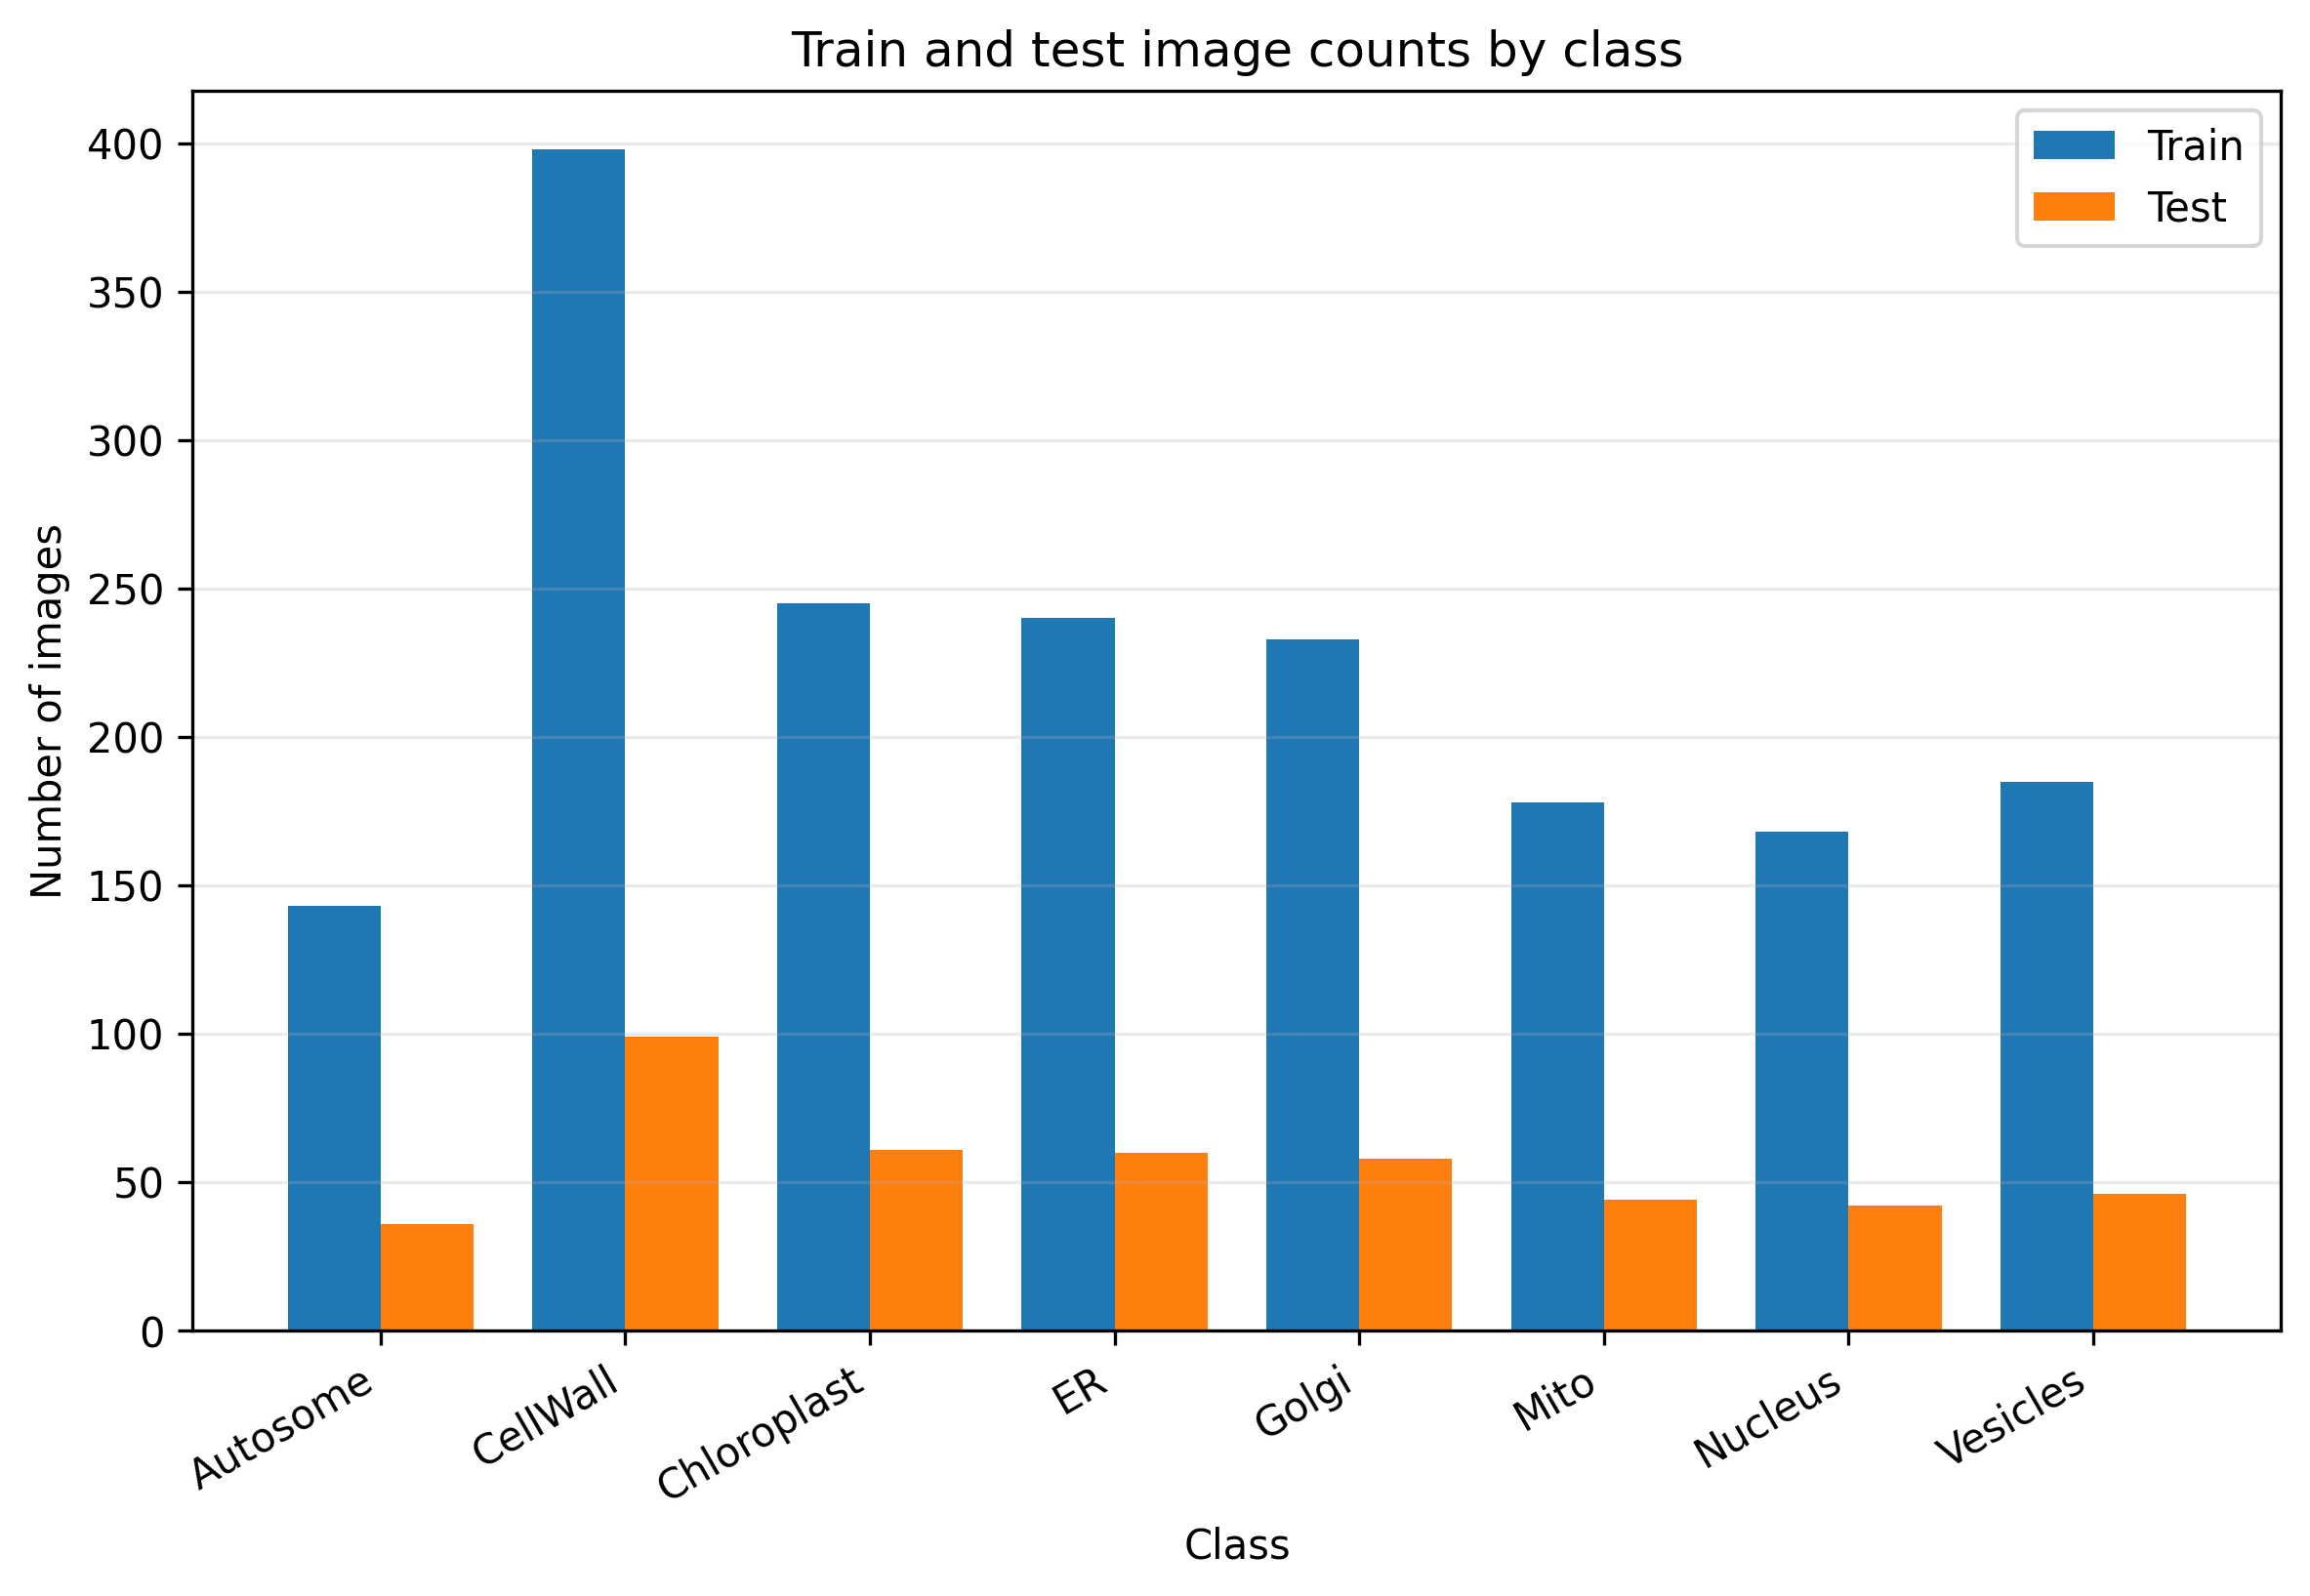

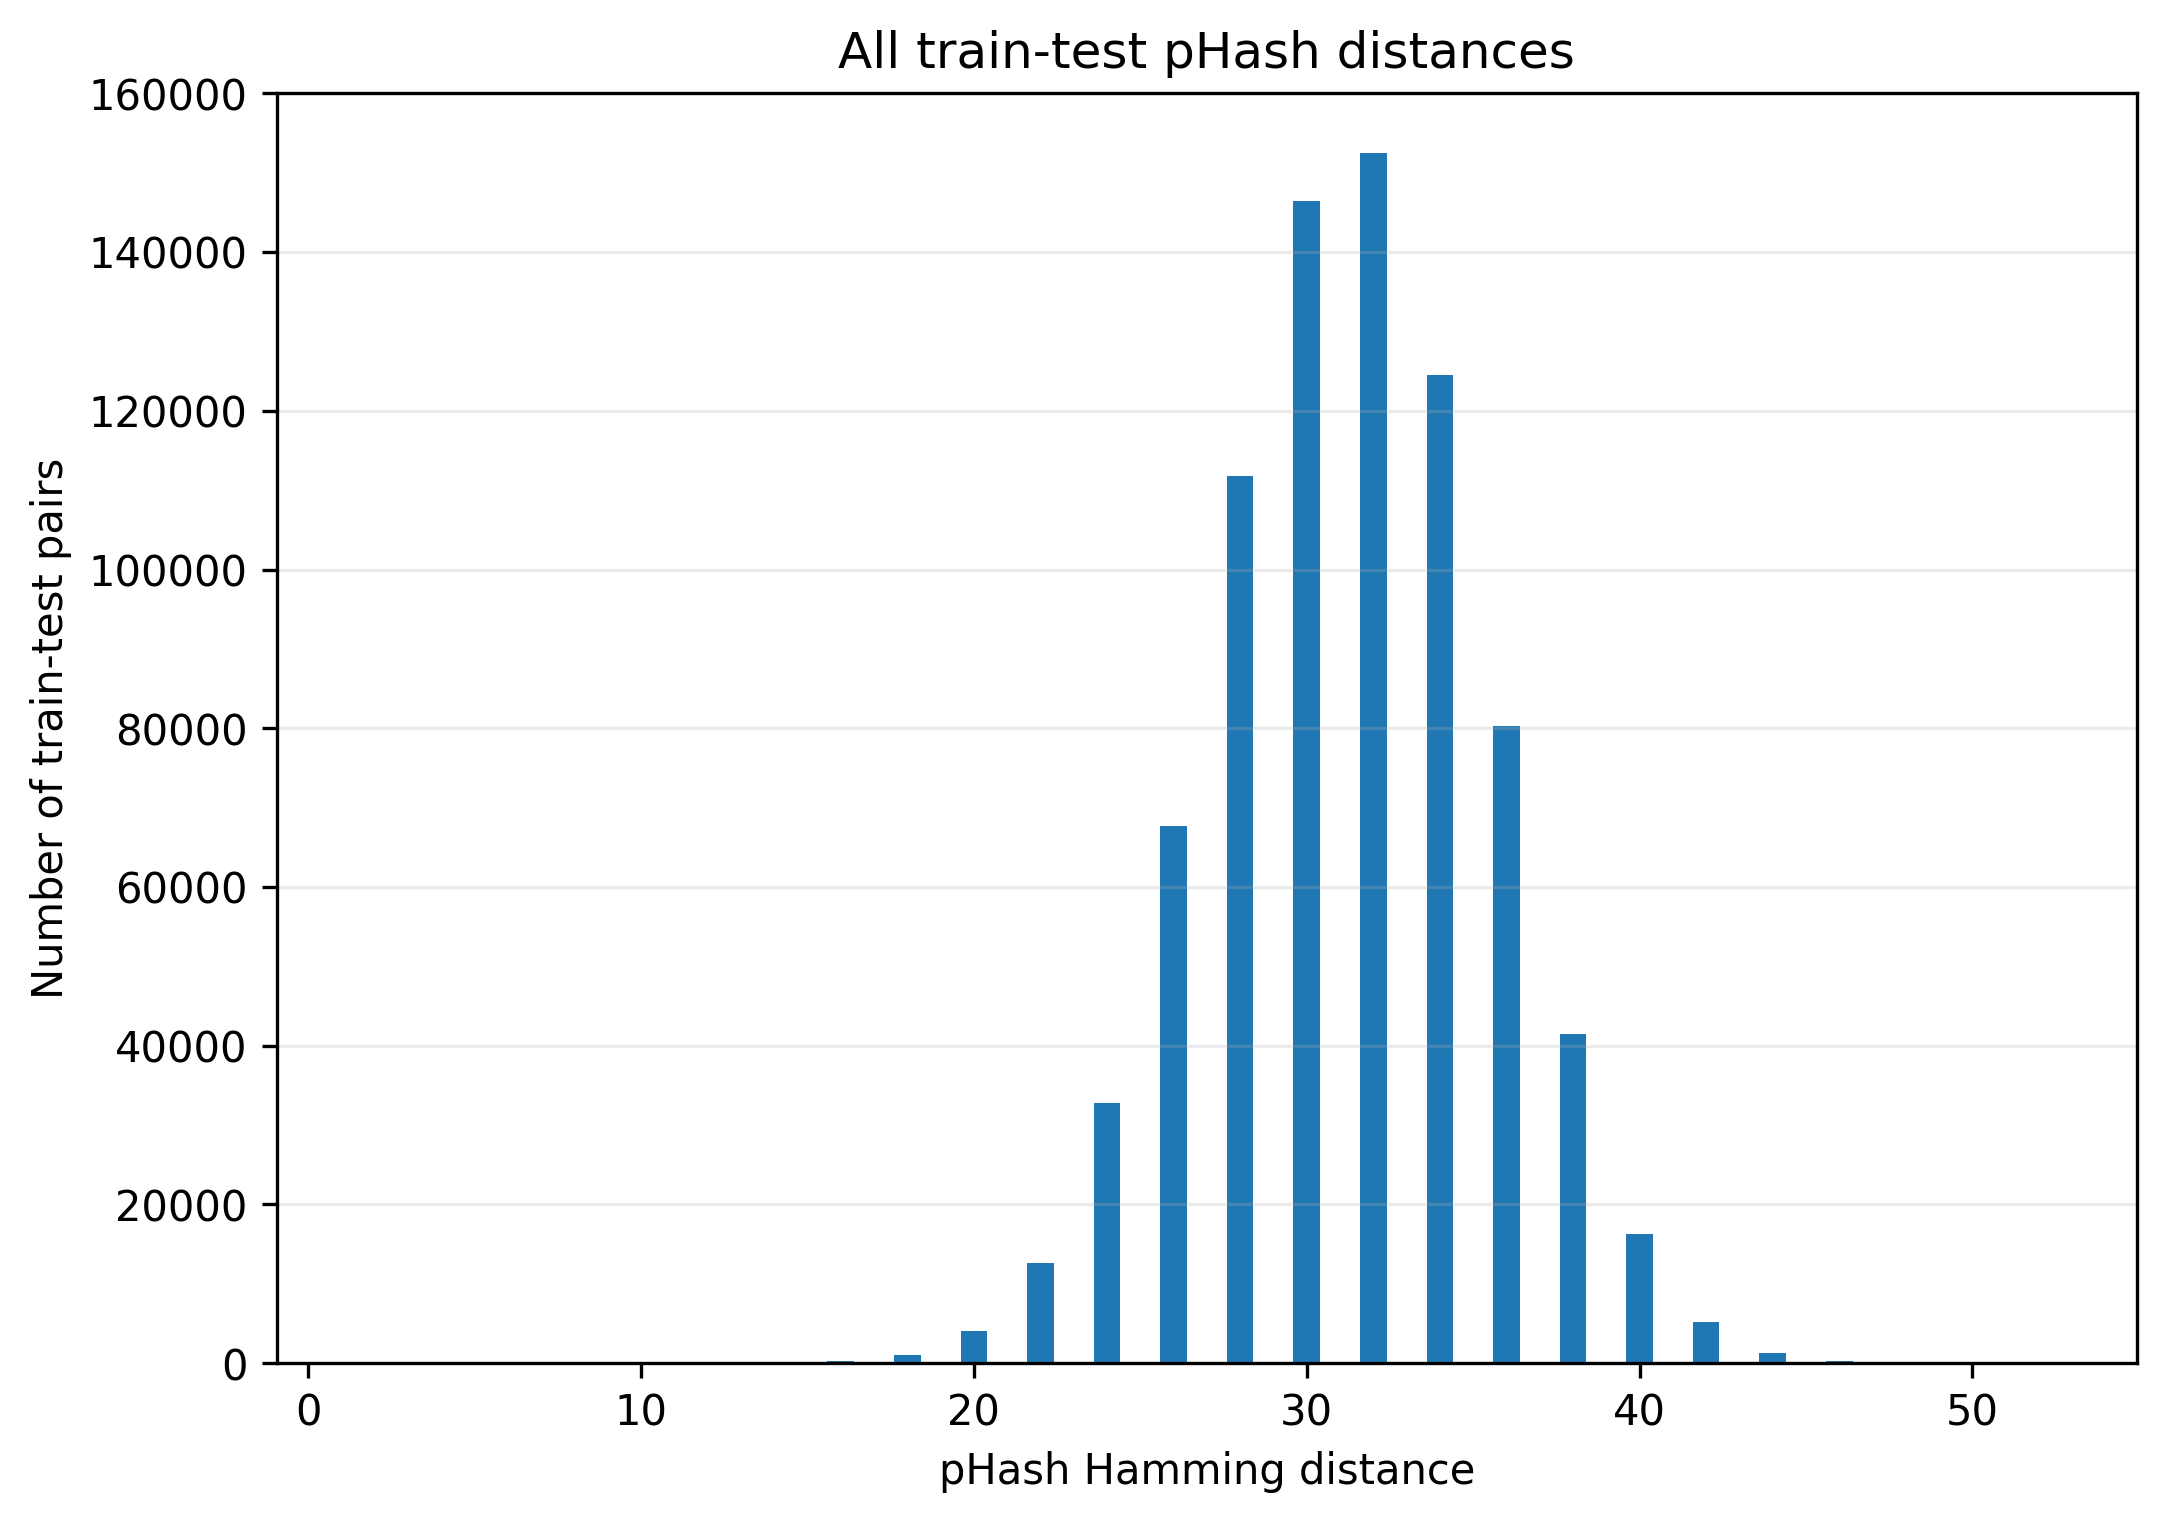

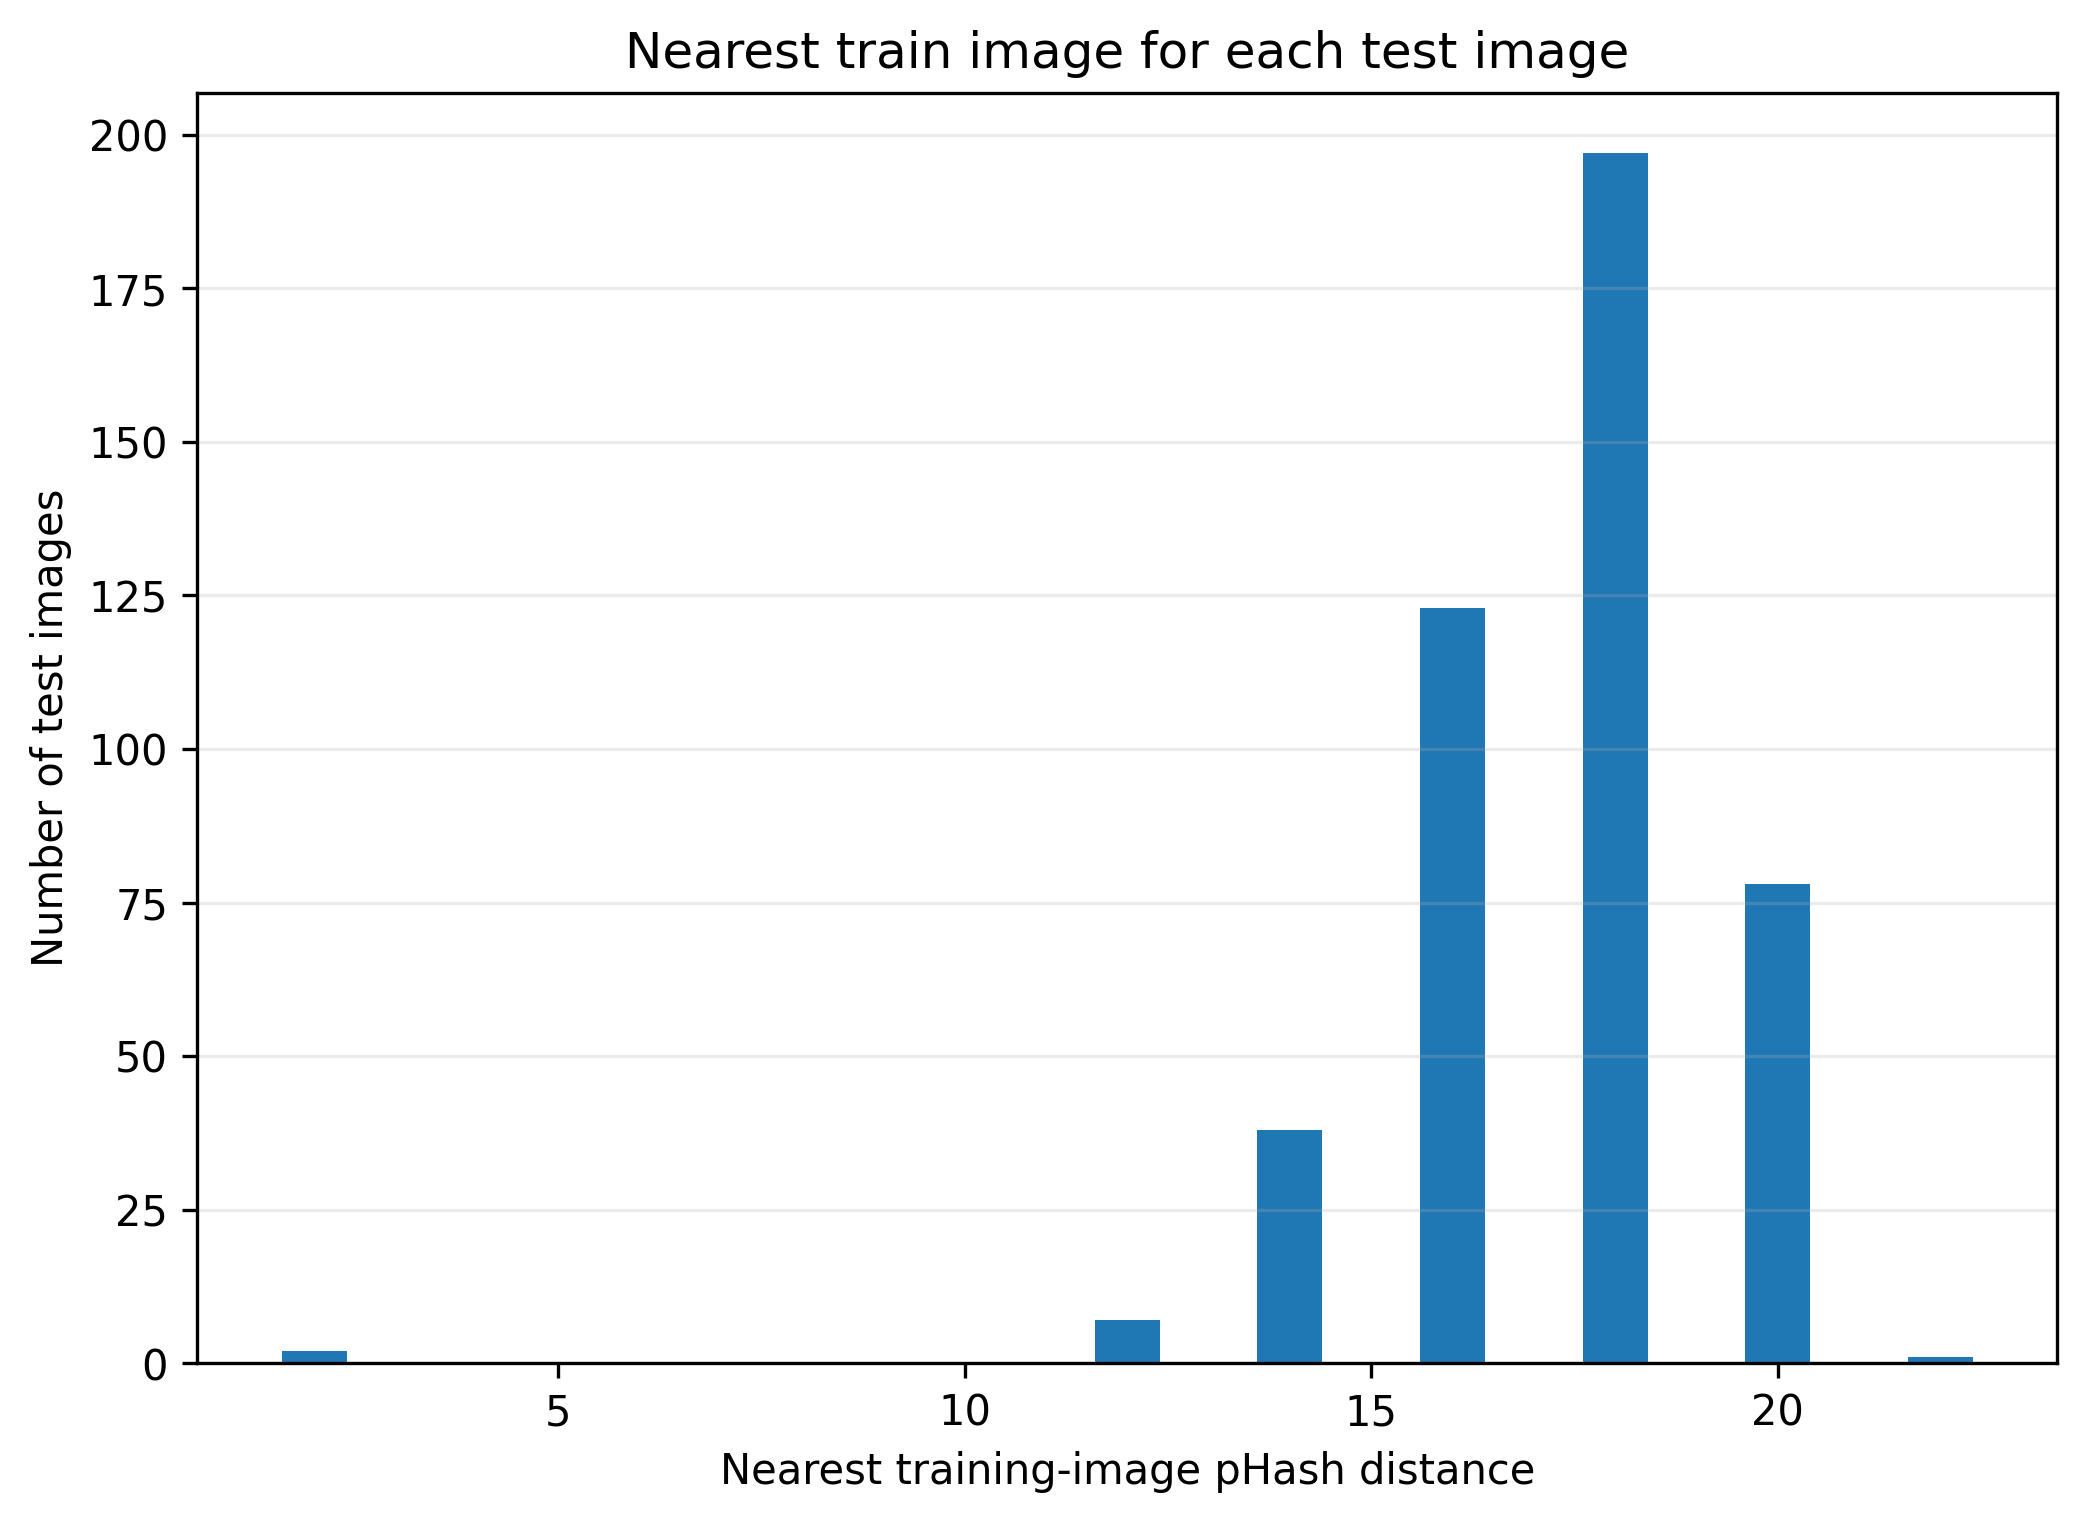

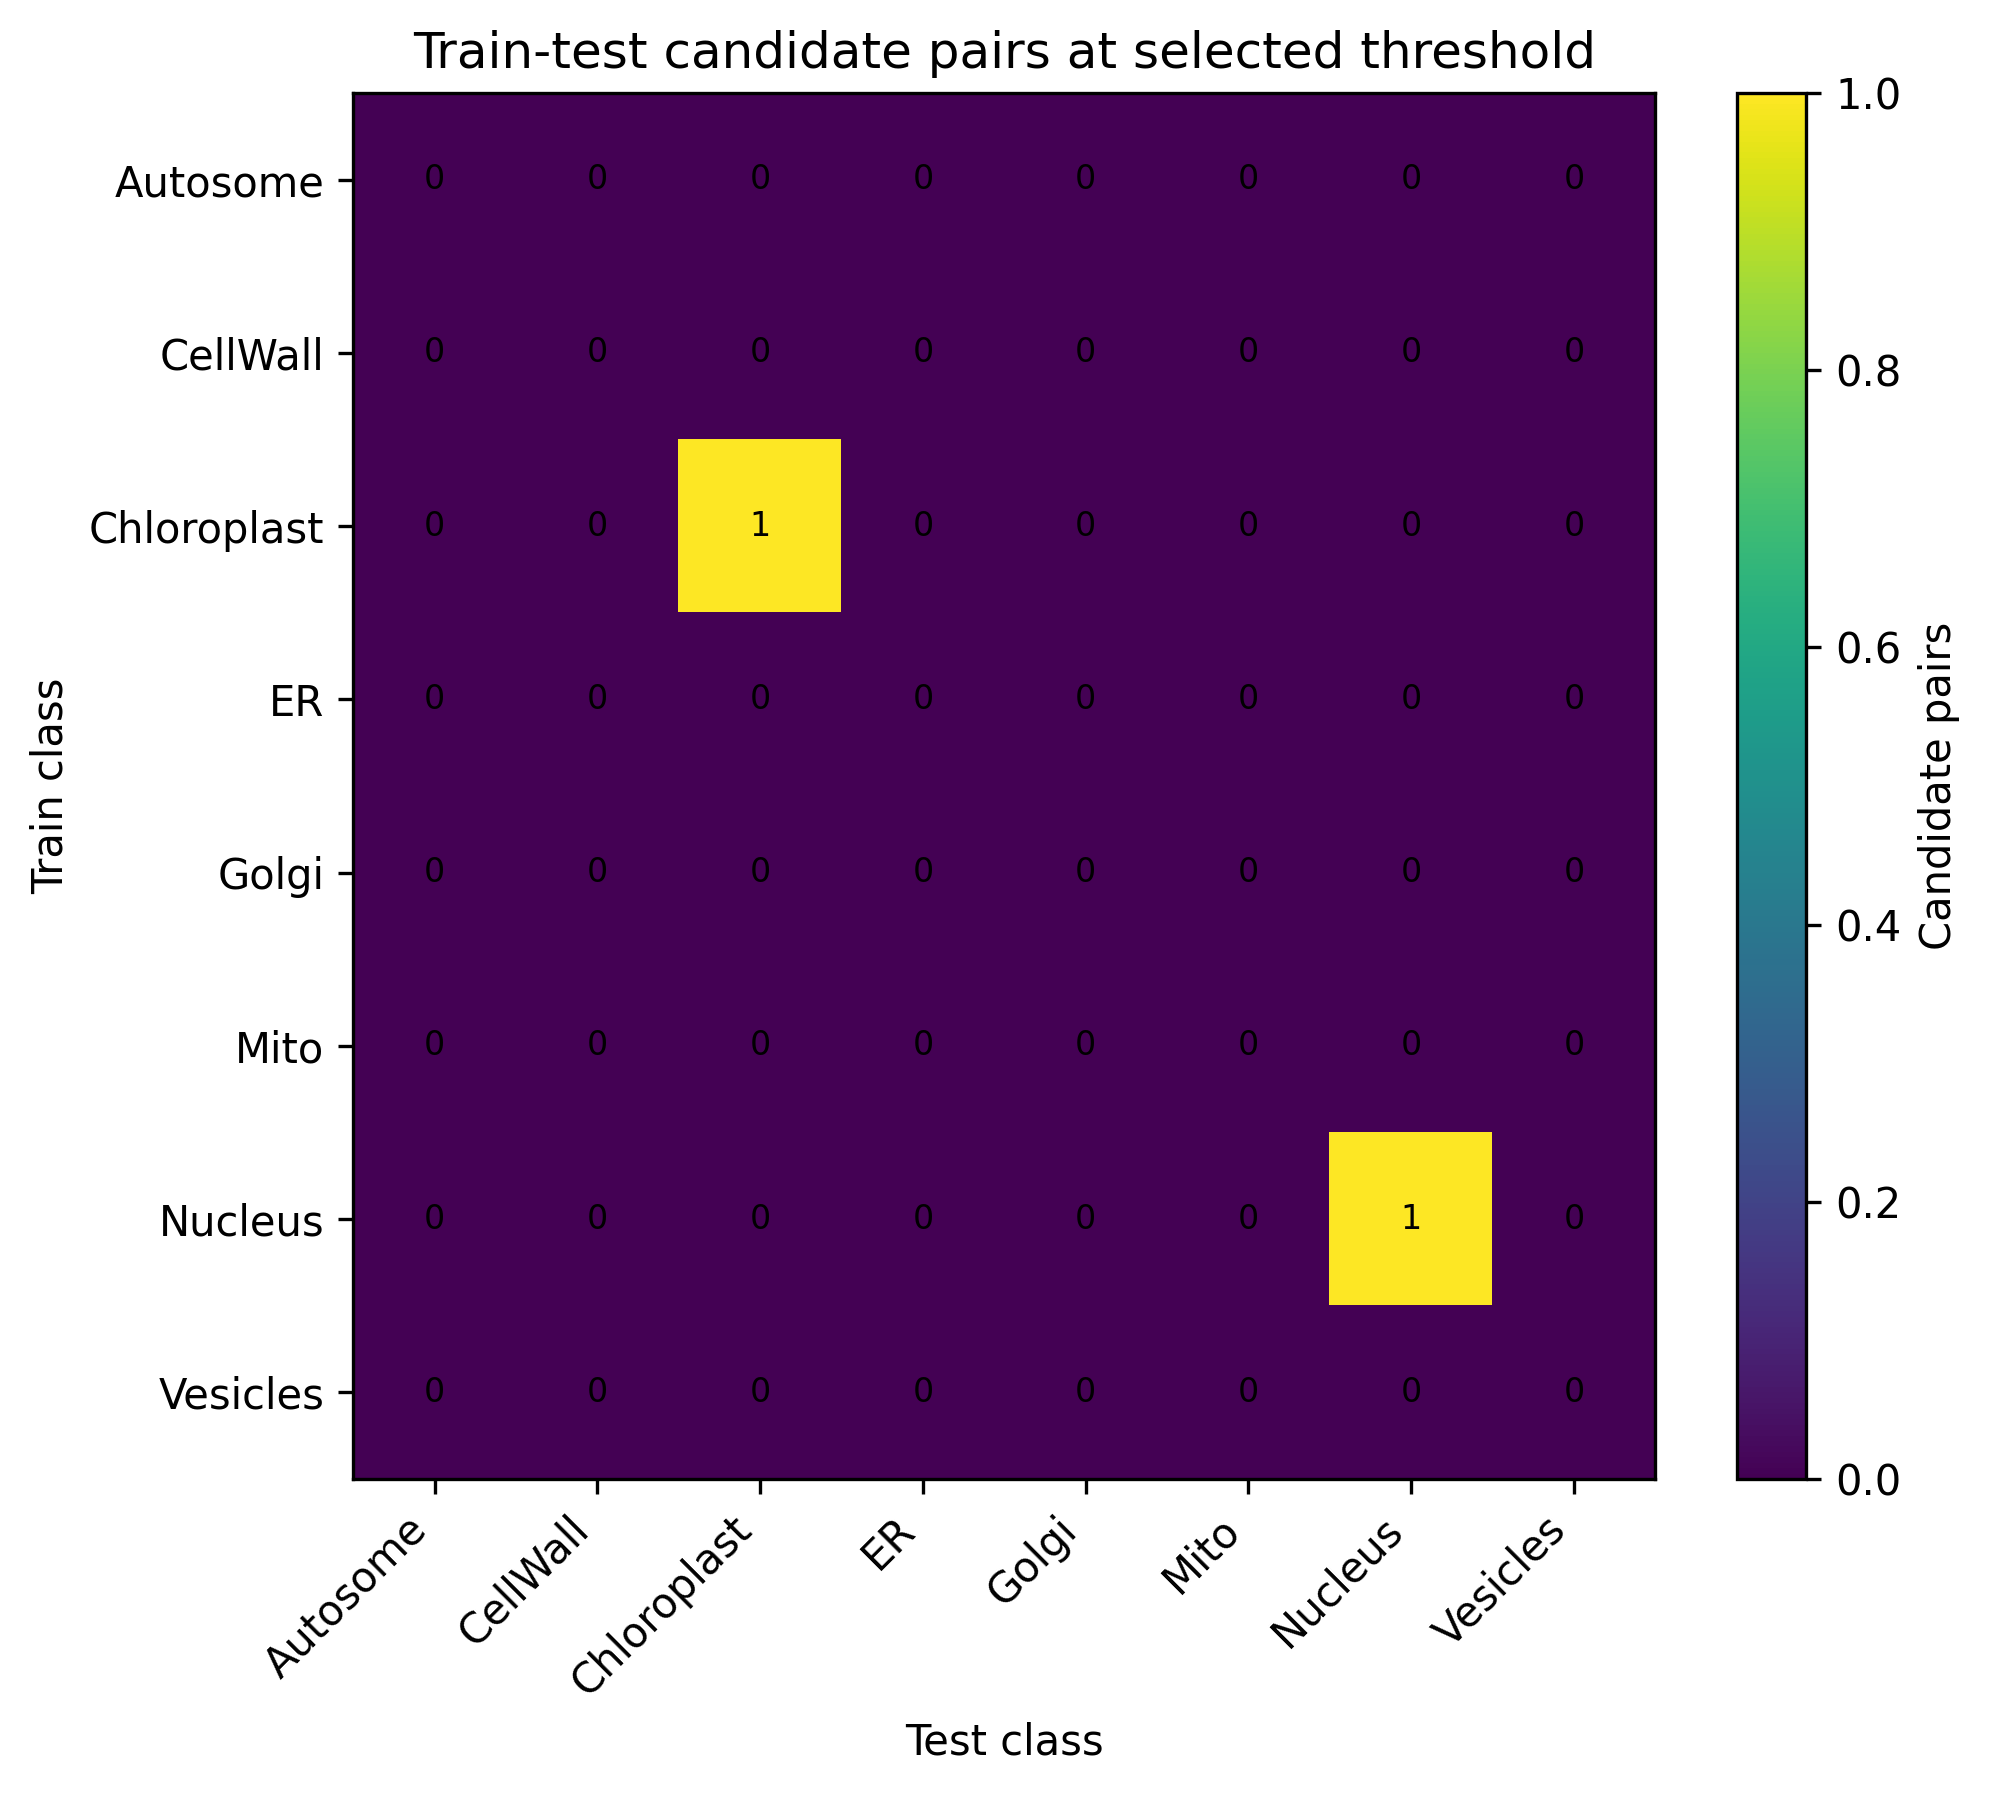

In [19]:
figure_paths = hash_plot.plot_hash_results(
    input_dir=saved_output_dir,
    output_dir=saved_output_dir / "figures",
    dpi=300,
)

for figure_path in figure_paths:
    if figure_path.suffix.lower() == ".png":
        display(NotebookImage(filename=str(figure_path), width=900))
